In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import spearmanr

## Cargamos los datos

In [9]:
df = pd.read_parquet(r"C:\Users\gemma\ProjecteData\Equip_15\Data\RRHH_220925_clean.parquet")
df.dtypes

ID                                  int64
Reason_absence             string[python]
Month_absence              string[python]
Day_week                   string[python]
Seasons                    string[python]
Transportation_expense            float64
Distance_Residence_Work           float64
Service_time                      float64
Age                               float64
Work_load_Average_day             float64
Hit_target                        float64
Disciplinary_failure                int64
Education                  string[python]
Son                                 int64
Social_drinker                      int64
Social_smoker                       int64
Pet                                 int64
Weight                            float64
Height                            float64
Body_mass_index                   float64
Absenteeism_hours                 float64
Education_numeric                   int64
Month_absence_order                 int64
Day_week_order                    

# Plan de análisis

## Objetivo del análisis 

Determinar qué características de los empleados están asociadas con un mayor desempeno laboral.

Consideraremos que nuestro indicador de desempeno laboral es la variable hit_target.

## Valoración de análisis que se pueden realizar

### Correlación entre hit target y variables numéricas

Analizar la correlación entre hit_target y características de los empleados.

¿Qué variables analizamos? Considerar desde un punto de vista teórico, en base a artículos, qué características personales de los trabajadores pueden influir en el desempeno laboral. 

### Relación entre hit target y variables categóricas

Aquí haremos visualizaciones (e.g. boxplots) y tests estadisticos para comparar hit rate a través de las categorías.

Para categóricas binarias → t-test / Mann-Whitney (en función de si la distribución es normal o no).

Para categóricas multinivel → ANOVA / Kruskal-Wallis.

### Modelo predictivo (regresión lineal múltiple)

Predecir el hit_target en base a las características de los empleados. De esta forma, introduciendo sus características, podremos predecir su productividad. Esto nos servirá para saber qué perfil de personas contratar en el futuro. 

Empezaremos con un modelo que incluya todas las variables. Mediante un proceso de selección stepwise determinaremos cuál es el modelo que, con el mínimo número de variables, es capaz de explicar en mayor medida la variabilidad de la variable de respuesta. En otras palabras, nos quedaremos con las variables más importante a la hora de predecir la productividad. Finalmente, determinaremos qué peso tiene cada variable. 

# Correlación entre hit target y variables numéricas

In [10]:
pd.set_option("display.max.columns", None)
# Calculamos la media de hit target de cada trabajador y nos quedamos con un solo registro por trabajador 
df['Hit_target_avg'] = df.groupby('ID')['Hit_target'].transform('mean')
df = df.drop_duplicates(subset=["ID"], keep="last").reset_index(drop=True)
df.head()

,ID,Reason_absence,Month_absence,Day_week,Seasons,Transportation_expense,Distance_Residence_Work,Service_time,Age,Work_load_Average_day,Hit_target,Disciplinary_failure,Education,Son,Social_drinker,Social_smoker,Pet,Weight,Height,Body_mass_index,Absenteeism_hours,Education_numeric,Month_absence_order,Day_week_order,Seasons_order,Hit_target_avg
0,6,13,Abril,Jueves,Verano,189.0,29.0,13.0,33.0,246.288,91.0,0,High school,2,0,0,2,69.0,167.0,25.0,8.0,1,4,5,3,94.875000
1,16,7,Junio,Miercoles,Verano,118.0,15.0,24.0,46.0,275.089,96.0,0,High school,2,1,1,0,75.0,175.0,25.0,8.0,1,6,4,3,97.500000
2,25,23,Mayo,Jueves,Verano,235.0,16.0,8.0,32.0,237.656,99.0,0,Postgraduate,0,0,0,0,75.0,178.0,25.0,2.0,3,5,5,3,95.600000
3,12,19,Julio,Viernes,Invierno,233.0,51.0,1.0,31.0,264.604,93.0,0,Graduate,1,1,0,8,68.0,178.0,21.0,2.0,2,7,6,1,96.142857
4,27,23,Febrero,Viernes,Otono,184.0,42.0,7.0,27.0,302.585,99.0,0,High school,0,0,0,0,58.0,167.0,21.0,1.0,1,2,6,2,95.166667


Correlaciones significativas con Hit_target_avg:
                            rho      pval
Work_load_Average_day -0.203923  0.017253


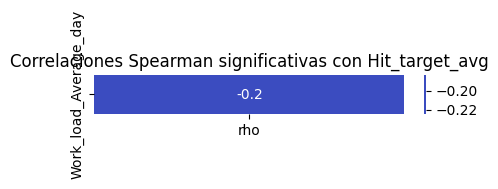

In [11]:
# Variables de interés
vars_interes = [
    "Transportation_expense","Distance_Residence_Work","Service_time","Age",
    "Work_load_Average_day","Son","Weight","Height","Body_mass_index"
]

target = "Hit_target_avg"
results = {}

# Calcular rho y p-valor para cada variable de interés
for col in vars_interes:
    rho, pval = spearmanr(df[target], df[col], nan_policy="omit")
    results[col] = {"rho": rho, "pval": pval}

# Convertimos a DataFrame
res_df = pd.DataFrame(results).T

# Filtramos las significativas (p < 0.05)
sig_res = res_df[res_df["pval"] < 0.05].sort_values("rho", ascending=False)

# Mostrar resultados
print("Correlaciones significativas con Hit_target_avg:")
print(sig_res)

# Graficar heatmap solo de las significativas
if not sig_res.empty:
    plt.figure(figsize=(5, len(sig_res) * 0.5))
    sns.heatmap(sig_res[["rho"]], annot=True, cmap="coolwarm", center=0)
    plt.title("Correlaciones Spearman significativas con Hit_target_avg")
    plt.show()
else:
    print("⚠️ Ninguna correlación significativa encontrada.")


## Relación entre hit target y variables categóricas

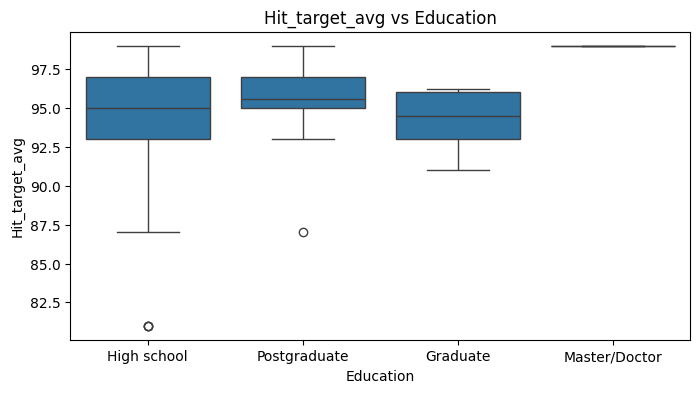

Education - p-value Kruskal-Wallis: 0.2119


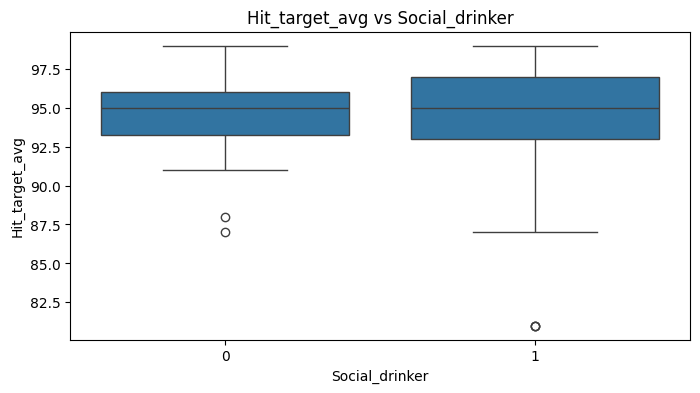

Social_drinker - p-value Mann-Whitney U: 0.8679


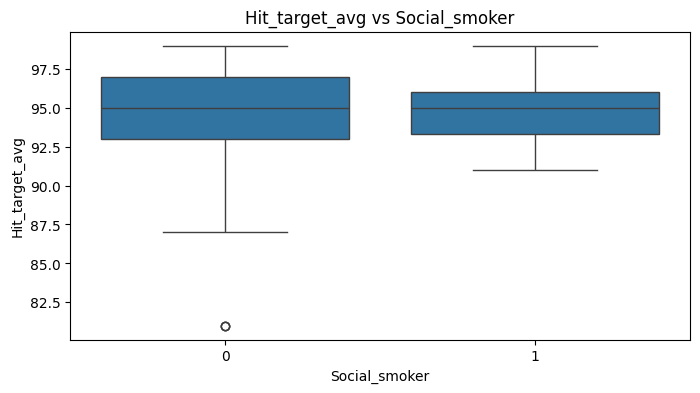

Social_smoker - p-value Mann-Whitney U: 0.9658


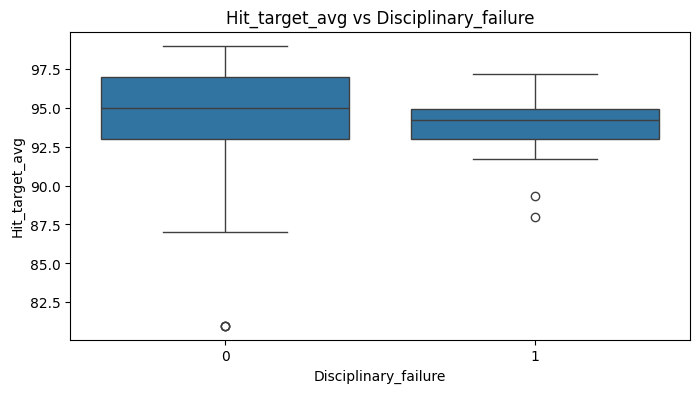

Disciplinary_failure - p-value Mann-Whitney U: 0.0219


In [12]:
cat_vars = ['Education', 'Social_drinker', 'Social_smoker', 'Disciplinary_failure']

for col in cat_vars:
    # Boxplots
    plt.figure(figsize=(8,4))
    sns.boxplot(x=col, y=target, data=df)
    plt.title(f"{target} vs {col}")
    plt.show()
    
    # Separar en grups
    groups = [group[target].values for name, group in df.groupby(col)]
    
    # Kruskal-Wallis per Education
    if col == "Education" and len(groups) > 1:
        kruskal = stats.kruskal(*groups)
        print(f"{col} - p-value Kruskal-Wallis: {kruskal.pvalue:.4f}")
    
    # Mann-Whitney U per variables binàries
    elif len(groups) == 2:
        mannwhitney = stats.mannwhitneyu(groups[0], groups[1], alternative="two-sided")
        print(f"{col} - p-value Mann-Whitney U: {mannwhitney.pvalue:.4f}")
    else:
        print(f"{col} - No s'ha aplicat test estadístic")


## Modelo predictivo

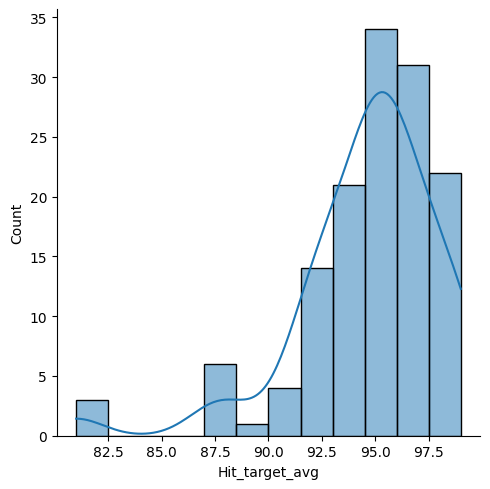

In [13]:
sns.displot(data=df["Hit_target_avg"], kde=True )

In [ ]:
# Passar les categòriques/binomials a object
cat_vars = ['Education', 'Social_drinker', 'Social_smoker', 'Disciplinary_failure']
for col in cat_vars:
    df[col] = df[col].astype(str).str.strip()

df.dtypes

ID                                  int64
Reason_absence             string[python]
Month_absence              string[python]
Day_week                   string[python]
Seasons                    string[python]
Transportation_expense            float64
Distance_Residence_Work           float64
Service_time                      float64
Age                               float64
Work_load_Average_day             float64
Hit_target                        float64
Disciplinary_failure               object
Education                          object
Son                                 int64
Social_drinker                     object
Social_smoker                      object
Pet                                 int64
Weight                            float64
Height                            float64
Body_mass_index                   float64
Absenteeism_hours                 float64
Education_numeric                   int64
Month_absence_order                 int64
Day_week_order                    

In [18]:
import numpy as np
import statsmodels.formula.api as smf

# 1. Escalar la resposta a [0,1]
df["Hit_target_scaled"] = df["Hit_target_avg"] / 100

# 2. Ajustar els valors per evitar 0 i 1 exactes (sinó el logit peta)
eps = 1e-6
df["Hit_target_scaled"] = df["Hit_target_scaled"].clip(eps, 1 - eps)

# 3. Transformació logit
df["Hit_target_logit"] = np.log(df["Hit_target_scaled"] / (1 - df["Hit_target_scaled"]))

# 4. Definir la fórmula del model amb predictors
formula = 'Hit_target_logit ~  Transportation_expense + Distance_Residence_Work + Service_time + Age + Work_load_Average_day + Son + Weight + Height + Body_mass_index + Education + Social_drinker + Social_smoker + Disciplinary_failure'

# 5. Ajustar regressió lineal (OLS)
model = smf.glm(formula, data=df).fit()

# 6. Resultats
print(model.summary())

# 7. Si vols prediccions en l'escala original (0-100):
df["pred_logit"] = model.predict(df)
df["pred_scaled"] = 1 / (1 + np.exp(-df["pred_logit"]))  # inverse logit
df["pred_original"] = df["pred_scaled"] * 100


                 Generalized Linear Model Regression Results                  
Dep. Variable:       Hit_target_logit   No. Observations:                  136
Model:                            GLM   Df Residuals:                      120
Model Family:                Gaussian   Df Model:                           15
Link Function:               Identity   Scale:                         0.47415
Method:                          IRLS   Log-Likelihood:                -133.72
Date:                Fri, 26 Sep 2025   Deviance:                       56.898
Time:                        20:02:48   Pearson chi2:                     56.9
No. Iterations:                     3   Pseudo R-squ. (CS):             0.1927
Covariance Type:            nonrobust                                         
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept           

Fem la selecció dels predictors que tenen un efecte significatiu sobre la variable de resposta.

In [20]:
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# Variable resposta (transformada logit)
y = df["Hit_target_logit"]

# Variables predictors segons la teva fórmula
predictors = [
    "Transportation_expense", "Distance_Residence_Work", "Service_time", "Age",
    "Work_load_Average_day", "Son", "Weight", "Height", "Body_mass_index",
    "Education", "Social_drinker", "Social_smoker", "Disciplinary_failure"
]

# One-hot encoding per Education (4 nivells), drop_first=True per evitar colinearitat
X = pd.get_dummies(df[predictors], columns=["Education",'Social_drinker', 'Social_smoker', 'Disciplinary_failure'], drop_first=True)

# Pipeline: Standardització + LASSO amb cross-validation
lasso = make_pipeline(
    StandardScaler(),
    LassoCV(cv=5, random_state=0)
)

lasso.fit(X, y)

# Resultats dels coeficients
coefs = lasso.named_steps['lassocv'].coef_
selected = X.columns[coefs != 0]

results = pd.DataFrame({
    "Variable": X.columns,
    "Coef": coefs,
    "Selected": coefs != 0
})

print(results)
print("\nPredictors seleccionats per LASSO:", list(selected))


                   Variable          Coef  Selected
0    Transportation_expense -0.000000e+00     False
1   Distance_Residence_Work  0.000000e+00     False
2              Service_time  0.000000e+00     False
3                       Age  0.000000e+00     False
4     Work_load_Average_day -2.612289e-17      True
5                       Son -0.000000e+00     False
6                    Weight  0.000000e+00     False
7                    Height  0.000000e+00     False
8           Body_mass_index -0.000000e+00     False
9     Education_High school -0.000000e+00     False
10  Education_Master/Doctor  0.000000e+00     False
11   Education_Postgraduate  0.000000e+00     False
12         Social_drinker_1  0.000000e+00     False
13          Social_smoker_1 -0.000000e+00     False
14   Disciplinary_failure_1 -0.000000e+00     False

Predictors seleccionats per LASSO: ['Work_load_Average_day']


Tal com podíem anticipar amb la correlació, no hi ha cap predictor significatiu. Només work_load_average_day, la qual cosa és de lògica: com més paquets a repartir, menys probabilitat d'entregar-los tots. 